# Customer Churn Prediction

Predicting telecom customer churn from the **cleaned and feature-engineered** dataset (`Customer churn analysis.csv`) produced in the EDA notebook.

**Workflow:** load data → train/test split → preprocessing pipeline → compare 4 models → tune XGBoost → evaluate → feature importance → predict for a new customer.

## 1. Setup & data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
cp=pd.read_csv('Customer churn analysis.csv')

In [3]:
cp.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,MonthlyChargeGroup
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12 Months,Low
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,No,25-36 Months,Medium
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12 Months,Medium
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37-48 Months,Medium
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12 Months,High


## 2. Train / test split
Stratified 80/20 split so the churn ratio (~26.6%) is preserved in both sets.

In [4]:
x= cp.drop('Churn',axis=1)
y= cp['Churn'].map({"No":0,"Yes":1})
print(y.value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2,stratify=y)
print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (5625, 21)
Testing : (1407, 21)


## 3. Preprocessing
Scale numeric columns, one-hot encode categorical columns. Everything is inside a `Pipeline` so the encoder/scaler are fitted on training data only (no leakage).

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
numeric_features = ["tenure","MonthlyCharges","TotalCharges"]
categorical_features = [col for col in x.columns if col not in numeric_features]
preprocessor = ColumnTransformer(transformers=[("num",StandardScaler(),numeric_features),("cat",OneHotEncoder(handle_unknown="ignore",drop="first"),categorical_features)])

## 4. Baseline models
Logistic Regression, Decision Tree, Random Forest and XGBoost.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
lr = Pipeline(steps=[("preprocessor",preprocessor),("model",LogisticRegression(max_iter=1000,random_state=42))])
lr.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [8]:
y_pred_log = lr.predict(X_test)
y_prob_log = lr.predict_proba(X_test)[:,1]
print("Predictions:")
print(y_pred_log[:10])
print("\nChurn probabilities:")
print(y_prob_log[:10])

Predictions:
[0 1 0 0 0 0 0 0 1 0]

Churn probabilities:
[0.01598016 0.62841052 0.00826714 0.20808575 0.09290618 0.45928807
 0.02167769 0.16177914 0.65401552 0.01565634]


In [9]:
from sklearn.metrics import(accuracy_score,precision_score,recall_score,f1_score,roc_auc_score)
print("Accuracy:",round(accuracy_score(y_test,y_pred_log),4))
print("Precision:",round(precision_score(y_test,y_pred_log),4))
print("Recall:",round(recall_score(y_test,y_pred_log),4))
print("F1 Score:",round(f1_score(y_test,y_pred_log),4))
print("ROC-AUC:",round(roc_auc_score(y_test,y_prob_log),4))

Accuracy: 0.8038
Precision: 0.6612
Recall: 0.5374
F1 Score: 0.5929
ROC-AUC: 0.8359


In [10]:
from sklearn.tree import DecisionTreeClassifier
dt = Pipeline(steps=[('Preprocessor',preprocessor),("model",DecisionTreeClassifier(max_depth=5,random_state=42))])
dt.fit(X_train,y_train)

,steps,"[('Preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [11]:
y_pred_tree = dt.predict(X_test)
y_prob_tree = dt.predict_proba(X_test)[:,1]
print("Predictions:")
print(y_pred_tree[:10])
print("\nChurn probabilities:")
print(y_prob_tree[:10])

Predictions:
[0 1 0 0 0 0 0 0 1 0]

Churn probabilities:
[0.01065089 0.57312253 0.01065089 0.07936508 0.09302326 0.27173913
 0.0295082  0.08118081 0.74242424 0.01065089]


In [12]:
print("Accuracy:",round(accuracy_score(y_test,y_pred_tree),4))
print("F1 Score:",round(f1_score(y_test,y_pred_tree),4))
print("ROC-AUC:",round(roc_auc_score(y_test,y_prob_tree),4))

Accuracy: 0.7783
F1 Score: 0.5884
ROC-AUC: 0.8195


In [13]:
from sklearn.ensemble import RandomForestClassifier
rf = Pipeline(steps=[('preprocessor',preprocessor),('model',RandomForestClassifier(n_estimators=200,max_depth=10,random_state=42,n_jobs=-1))])
rf.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [14]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
print("Predictions:")
print(y_pred_rf[:10])
print("\nChurn probabilities:")
print(y_prob_rf[:10])

Predictions:
[0 1 0 0 0 0 0 0 1 0]

Churn probabilities:
[0.01409967 0.62367071 0.01989244 0.09274003 0.11535681 0.37717362
 0.0235572  0.11797479 0.60146658 0.00837198]


In [15]:
print("Accuracy:",round(accuracy_score(y_test,y_pred_rf),4))
print("F1 Score:",round(f1_score(y_test,y_pred_rf),4))
print("ROC-AUC:",round(roc_auc_score(y_test,y_prob_rf),4))

Accuracy: 0.7889
F1 Score: 0.5534
ROC-AUC: 0.834


In [16]:
from xgboost import XGBClassifier
xgb = Pipeline(steps=[('preprocessor',preprocessor),("model",XGBClassifier(n_estimators=200,max_depth=4,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,random_state=42,eval_metric="logloss",n_jobs=-1))])
xgb.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [17]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

In [18]:
print("Accuracy:",round(accuracy_score(y_test,y_pred_xgb),4))
print("F1 Score:",round(f1_score(y_test,y_pred_xgb),4))
print("ROC-AUC:",round(roc_auc_score(y_test,y_prob_xgb),4))

Accuracy: 0.7946
F1 Score: 0.5818
ROC-AUC: 0.8399


## 5. Hyperparameter tuning (XGBoost)
`scale_pos_weight` handles class imbalance; `GridSearchCV` (3-fold, scored on F1) picks the parameters.

In [19]:
from sklearn.model_selection import GridSearchCV
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_tuned = Pipeline(steps=[("preprocessor", preprocessor),("model", XGBClassifier(random_state=42,eval_metric="logloss",scale_pos_weight=scale_pos_weight,n_jobs=-1))])

In [20]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1]
}
grid_search = GridSearchCV(estimator=xgb_tuned,param_grid=param_grid,scoring="f1",cv=3,n_jobs=-1,verbose=1)
grid_search.fit(X_train, y_train)
print("Best Parameters:")
print(grid_search.best_params_)
best_model = grid_search.best_estimator_

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}


In [21]:
y_pred_final = best_model.predict(X_test)
y_prob_final = best_model.predict_proba(X_test)[:, 1]

In [22]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred_final)
print(cm)

[[721 312]
 [ 73 301]]


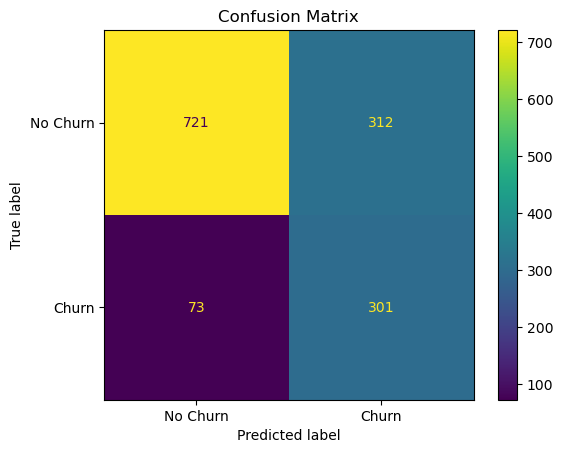

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
display = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["No Churn","Churn"])
display.plot()
plt.title("Confusion Matrix")
plt.show()

## 6. Model comparison

In [24]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "Tuned XGBoost"
    ],
     "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_final)
    ],

    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_final)
    ],

    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_final)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_final)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_tree),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_final)
    ]
})
results = results.round(4)
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8038,0.6612,0.5374,0.5929,0.8359
1,Decision Tree,0.7783,0.5807,0.5963,0.5884,0.8195
2,Random Forest,0.7889,0.6323,0.4920,0.5534,0.8340
3,XGBoost,0.7946,0.6341,0.5374,0.5818,0.8399
4,Tuned XGBoost,0.7264,0.4910,0.8048,0.6099,0.8402


In [25]:
best_model_row = results.loc[results["F1 Score"].idxmax()]
print("=" * 55)
print("              BEST MODEL")
print("          Based on F1 Score")
print("=" * 55)
print(f"Model      : {best_model_row['Model']}")
print(f"Accuracy   : {best_model_row['Accuracy'] * 100:.2f}%")
print(f"Precision  : {best_model_row['Precision'] * 100:.2f}%")
print(f"Recall     : {best_model_row['Recall'] * 100:.2f}%")
print(f"F1 Score   : {best_model_row['F1 Score'] * 100:.2f}%")
print(f"ROC-AUC    : {best_model_row['ROC-AUC'] * 100:.2f}%")
print("=" * 55)

              BEST MODEL
          Based on F1 Score
Model      : Tuned XGBoost
Accuracy   : 72.64%
Precision  : 49.10%
Recall     : 80.48%
F1 Score   : 60.99%
ROC-AUC    : 84.02%


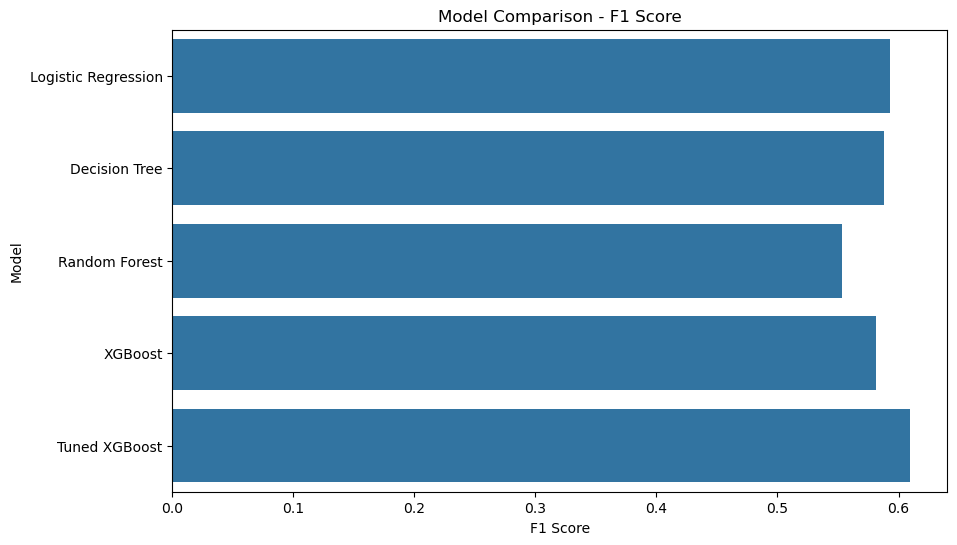

In [26]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results,x="F1 Score",y="Model")
plt.title("Model Comparison - F1 Score")
plt.xlabel("F1 Score")
plt.ylabel("Model")
plt.show()

## 7. Feature importance

In [27]:
preprocessor_fitted = (best_model.named_steps["preprocessor"])
model_fitted = (best_model.named_steps["model"])

In [28]:
feature_names = (preprocessor_fitted.get_feature_names_out())
print(feature_names)

['num__tenure' 'num__MonthlyCharges' 'num__TotalCharges'
 'cat__gender_Male' 'cat__SeniorCitizen_1' 'cat__Partner_Yes'
 'cat__Dependents_Yes' 'cat__PhoneService_Yes'
 'cat__MultipleLines_No phone service' 'cat__MultipleLines_Yes'
 'cat__InternetService_Fiber optic' 'cat__InternetService_No'
 'cat__OnlineSecurity_No internet service' 'cat__OnlineSecurity_Yes'
 'cat__OnlineBackup_No internet service' 'cat__OnlineBackup_Yes'
 'cat__DeviceProtection_No internet service' 'cat__DeviceProtection_Yes'
 'cat__TechSupport_No internet service' 'cat__TechSupport_Yes'
 'cat__StreamingTV_No internet service' 'cat__StreamingTV_Yes'
 'cat__StreamingMovies_No internet service' 'cat__StreamingMovies_Yes'
 'cat__Contract_One year' 'cat__Contract_Two year'
 'cat__PaperlessBilling_Yes' 'cat__PaymentMethod_Credit card (automatic)'
 'cat__PaymentMethod_Electronic check' 'cat__PaymentMethod_Mailed check'
 'cat__TenureGroup_13-24 Months' 'cat__TenureGroup_25-36 Months'
 'cat__TenureGroup_37-48 Months' 'cat__Te

In [29]:
feature_importance = pd.DataFrame({"Feature": feature_names,"Importance": model_fitted.feature_importances_})

In [30]:
feature_importance = (feature_importance.sort_values("Importance",ascending=False))
feature_importance.head(15)

,Feature,Importance
25,cat__Contract_Two year,0.255771
24,cat__Contract_One year,0.207339
10,cat__InternetService_Fiber optic,0.104850
11,cat__InternetService_No,0.100665
0,num__tenure,0.040674
28,cat__PaymentMethod_Electronic check,0.035022
23,cat__StreamingMovies_Yes,0.034973
13,cat__OnlineSecurity_Yes,0.026185
26,cat__PaperlessBilling_Yes,0.019218
21,cat__StreamingTV_Yes,0.016606


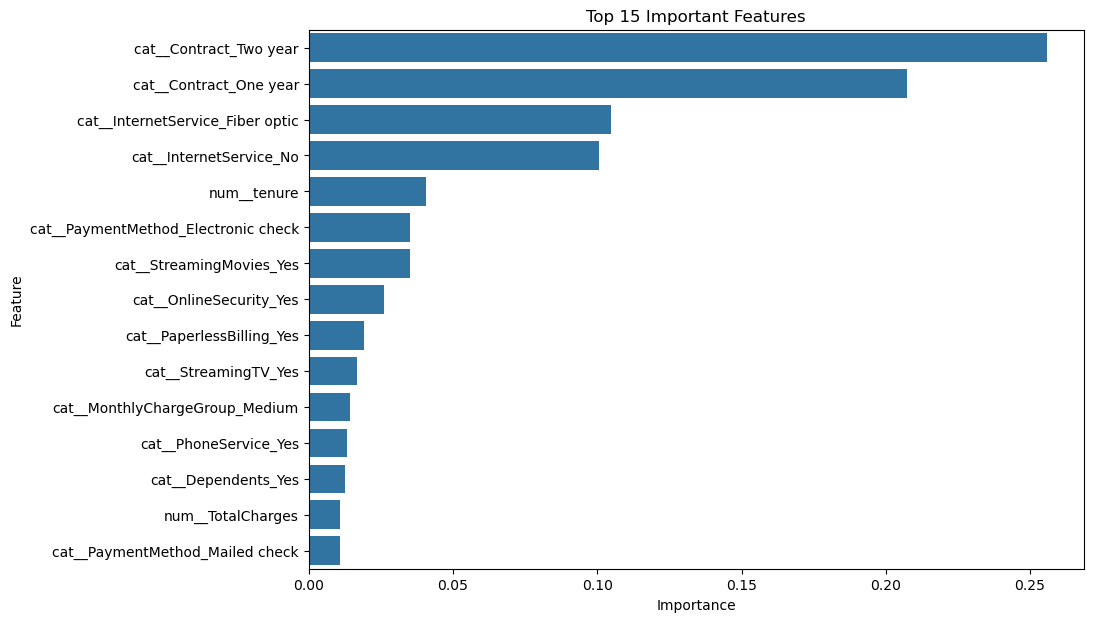

In [31]:
top_features = feature_importance.head(15)
plt.figure(figsize=(10, 7))
sns.barplot(data=top_features,x="Importance",y="Feature")
plt.title("Top 15 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 8. Predicting for a new customer
Build a customer record, add the same engineered features (`TenureGroup`, `MonthlyChargeGroup`), then predict with the final pipeline.

In [32]:
new_customer = pd.DataFrame({
    "gender": ["Male"],
    "SeniorCitizen": [0],
    "Partner": ["No"],
    "Dependents": ["No"],
    "tenure": [5],
    "PhoneService": ["Yes"],
    "MultipleLines": ["No"],
    "InternetService": ["Fiber optic"],
    "OnlineSecurity": ["No"],
    "OnlineBackup": ["No"],
    "DeviceProtection": ["No"],
    "TechSupport": ["No"],
    "StreamingTV": ["No"],
    "StreamingMovies": ["No"],
    "Contract": ["Month-to-month"],
    "PaperlessBilling": ["Yes"],
    "PaymentMethod": ["Electronic check"],
    "MonthlyCharges": [85.50],
    "TotalCharges": [427.50]
})

In [33]:
new_customer["TenureGroup"] = pd.cut(
    new_customer["tenure"],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=["0-12 Months", "13-24 Months", "25-36 Months", "37-48 Months", "49-60 Months", "61-72 Months"],
    include_lowest=True)

new_customer["MonthlyChargeGroup"] = pd.cut(
    new_customer["MonthlyCharges"],
    bins=[0, 30, 60, 90, 120],
    labels=["Low", "Medium", "High", "Very High"],
    include_lowest=True)

In [34]:
new_customer

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,TenureGroup,MonthlyChargeGroup
0,Male,0,No,No,5,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,85.5,427.5,0-12 Months,High


In [35]:
prediction = best_model.predict(new_customer)
probability = best_model.predict_proba(new_customer)[:, 1]

In [36]:
if prediction[0] == 1:
    print("Prediction: Customer is likely to CHURN")
else:
    print("Prediction: Customer is likely to STAY")
print("Churn Probability:",round(probability[0] * 100, 2),"%")

Prediction: Customer is likely to CHURN
Churn Probability: 83.71 %


In [37]:
churn_probability = probability[0]
if churn_probability >= 0.70:
    risk = "High Risk"
elif churn_probability >= 0.40:
    risk = "Moderate Risk"
else:
    risk = "Low Risk"
print("Risk Level:", risk)

Risk Level: High Risk


## 9. Save the model (optional)
Saves the full pipeline (preprocessing + model) so it can be reused without retraining.

In [38]:
import joblib
joblib.dump(best_model, 'churn_model.joblib')

['churn_model.joblib']